# Experiment 9 — Cross-Experiment Analysis and Comparative Interpretation

This notebook performs a comparative analysis across all experimental conditions investigated throughout the project.

The purpose of the analysis is to identify broader patterns regarding:
- preprocessing effectiveness,
- inductive bias,
- model robustness,
- representation quality,
- computational efficiency,
- and model complexity.

Rather than evaluating experiments individually, this notebook attempts to synthesize the findings across all degradation conditions and preprocessing levels in order to better understand how representation quality interacts with different machine learning paradigms.

Personally, I find this stage particularly interesting because isolated experiments often reveal only partial explanations. It is only when the results are viewed collectively that broader structural patterns begin to emerge regarding robustness, representation quality, and the practical trade-offs between simple and complex models.

## Project Path Configuration

The notebook explicitly adds the project root directory to the Python path in order to ensure that the centralized experimental framework within the `src/` directory can be imported consistently across notebooks.

In [1]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

## Importing Analysis Libraries

The notebook imports the libraries required for loading experimental results, combining experiment outputs, and generating comparative visualizations.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

## Loading Experimental Results

The previously generated experiment results are loaded from the centralized results directory structure.

In [3]:
RESULTS_PATH = Path("../results/metrics")

In [4]:
baseline_results = pd.read_csv(
    RESULTS_PATH / "baseline_results.csv"
)

preprocessing_results = pd.read_csv(
    RESULTS_PATH / "preprocessing_levels_results.csv"
)

missingness_results = pd.read_csv(
    RESULTS_PATH / "missingness_results.csv"
)

noise_results = pd.read_csv(
    RESULTS_PATH / "noise_results.csv"
)

feature_results = pd.read_csv(
    RESULTS_PATH / "feature_relevance_results.csv"
)

imbalance_results = pd.read_csv(
    RESULTS_PATH / "class_imbalance_results.csv"
)

dataset_results = pd.read_csv(
    RESULTS_PATH / "dataset_size_results.csv"
)

cost_results = pd.read_csv(
    RESULTS_PATH / "computational_cost_results.csv"
)

## Constructing Comparative Experiment Summaries

The experiments are summarized using mean F1-score values in order to support cross-experiment comparison.

In [5]:
experiment_summary = pd.DataFrame({

    "Baseline":
        baseline_results.groupby("model")["f1_score"].mean(),

    "Preprocessing":
        preprocessing_results.groupby("model")["f1_score"].mean(),

    "Missingness":
        missingness_results.groupby("model")["f1_score"].mean(),

    "Noise":
        noise_results.groupby("model")["f1_score"].mean(),

    "Feature Relevance":
        feature_results.groupby("model")["f1_score"].mean(),

    "Class Imbalance":
        imbalance_results.groupby("model")["f1_score"].mean(),

    "Dataset Size":
        dataset_results.groupby("model")["f1_score"].mean()

})

experiment_summary

,Baseline,Preprocessing,Missingness,Noise,Feature Relevance,Class Imbalance,Dataset Size
model,,,,,,,
Decision Tree,0.621931,0.619372,0.580245,0.618716,0.613545,0.422011,0.609765
Logistic Regression,0.676501,0.582845,0.548603,0.582673,0.582880,0.332037,0.585940
MLP,0.658799,0.613601,0.536422,0.561320,0.578428,0.347725,0.586091
Naive Bayes,0.537425,0.525308,0.497721,0.525165,0.526947,0.293981,0.522714


## Cross-Experiment Performance Visualization

The following figure compares average model performance across all experimental conditions.

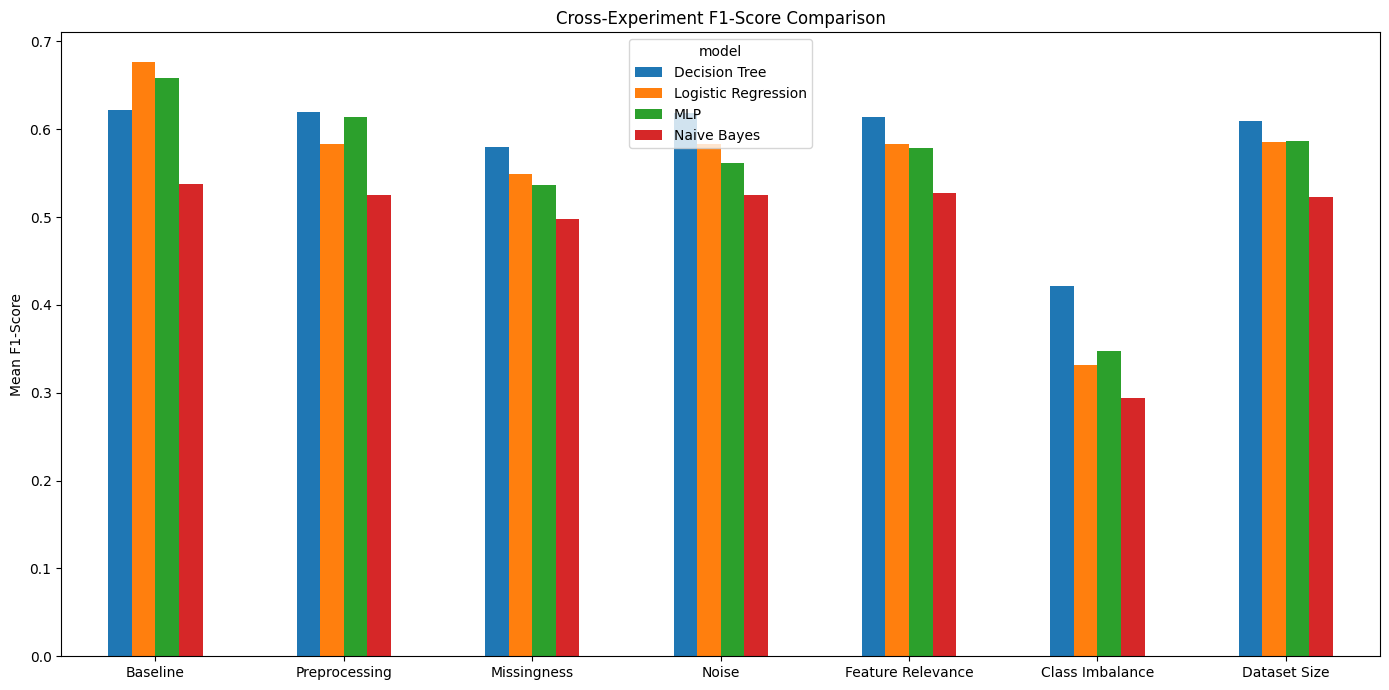

In [6]:
experiment_summary.T.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    "Cross-Experiment F1-Score Comparison"
)

plt.ylabel("Mean F1-Score")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

## Robustness Comparison

The following analysis examines how consistently models maintain predictive performance across degradation conditions.

In [7]:
robustness_summary = (
    experiment_summary.std(axis=1)
    .sort_values()
    .to_frame(name="performance_variability")
)

robustness_summary

,performance_variability
model,
Decision Tree,0.072670
Naive Bayes,0.087226
MLP,0.099223
Logistic Regression,0.106290


## Robustness Visualization

Lower variability indicates greater robustness across experimental conditions.

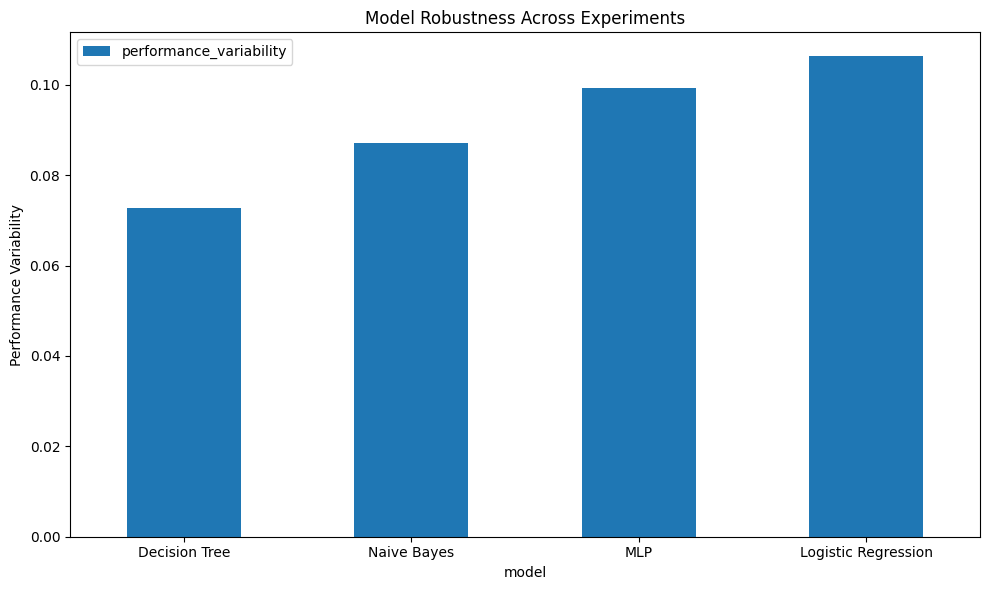

In [8]:
robustness_summary.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Model Robustness Across Experiments"
)

plt.ylabel(
    "Performance Variability"
)

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

## Representation Quality and Robustness Trends

The combined experiments reveal several broader trends regarding preprocessing effectiveness and representation quality.

Across nearly all degradation conditions, engineered preprocessing consistently improves predictive robustness relative to raw preprocessing conditions. This pattern appears especially strong for Logistic Regression, Naive Bayes, and the Multi-Layer Perceptron (MLP).

One particularly interesting observation is that preprocessing improvements frequently produce performance gains comparable to — or greater than — increases in model complexity alone. In several experiments, comparatively simple classical models become highly competitive once representation quality improves sufficiently.

At the same time, more flexible neural architectures still maintain advantages under several degraded conditions, particularly when the representation space becomes highly noisy or structurally unstable.

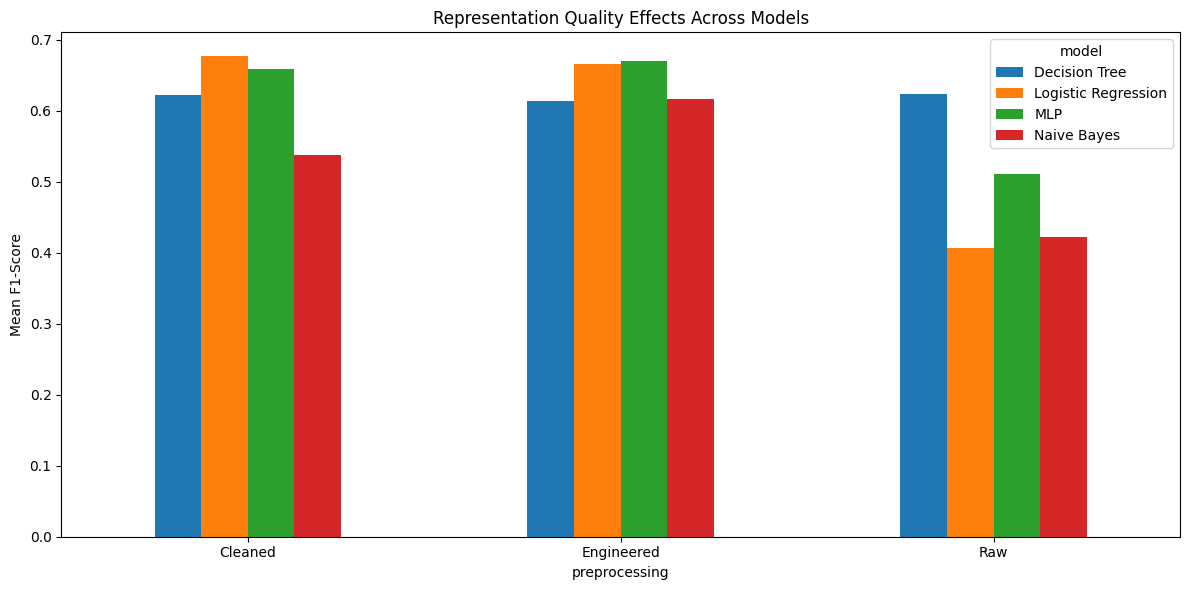

In [9]:
preprocessing_comparison = (
    preprocessing_results
    .groupby(["preprocessing", "model"])["f1_score"]
    .mean()
    .unstack()
)

preprocessing_comparison.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Representation Quality Effects Across Models"
)

plt.ylabel("Mean F1-Score")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

## Comparative Interpretation

The cross-experiment analysis reveals several broader patterns regarding preprocessing effectiveness, inductive bias, robustness, and model complexity.

One of the clearest findings throughout the project is that preprocessing quality consistently influences predictive performance across nearly all experimental conditions. In many cases, improvements in representation quality produced performance gains comparable to — or greater than — differences in model complexity itself.

Logistic Regression repeatedly demonstrated strong dependence on preprocessing quality. Under raw preprocessing conditions, performance frequently deteriorated substantially across degradation experiments. However, once preprocessing quality improved, the model often became highly competitive with considerably more flexible architectures. This suggests that simpler inductive biases may perform surprisingly well when the representation space aligns effectively with the assumptions embedded within the model.

The Multi-Layer Perceptron (MLP) consistently demonstrated strong predictive capacity, particularly under engineered preprocessing conditions. At the same time, the neural network frequently exhibited substantial sensitivity to degraded or poorly structured representations under raw preprocessing conditions. Personally, I initially expected the neural network to demonstrate greater robustness independently of preprocessing quality, but the results instead suggest that representation refinement remains highly important even for flexible models with greater representational capacity.

Naive Bayes demonstrated some of the most dramatic responses to preprocessing improvements. Although the model often performed comparatively weakly under raw preprocessing conditions, engineered preprocessing frequently improved performance substantially. One possible interpretation is that representation refinement reduces unstable or noisy feature dependencies and improves alignment with the model’s conditional independence assumptions.

Decision Trees remained comparatively stable across most experimental conditions. Although their peak predictive performance generally remained slightly below the strongest-performing models, they frequently demonstrated relatively strong robustness under degraded conditions. This stability may reflect the comparatively localized decision structure embedded within tree-based learning.

Another important pattern concerns the relationship between predictive performance and computational cost. The computational cost experiment revealed that more complex models did not always produce proportionally greater predictive gains relative to resource consumption. In several cases, comparatively simple models achieved highly competitive results while requiring substantially fewer computational resources.

Overall, the combined findings increasingly support the broader motivation of the project: in tabular machine learning tasks, predictive performance appears to depend not only on model complexity itself, but also on how effectively the representation quality of the data aligns with the inductive biases embedded within different learning algorithms.

In several cases, careful preprocessing and representation refinement appeared capable of shifting part of the modeling effort from the model itself into the structure of the data representation. Personally, I think this is one of the most interesting aspects of practical machine learning, because it challenges the common assumption that better performance necessarily requires increasingly complex models.